In [58]:
import pandas as pd

In [298]:
def busqueda(expression,column,name=None):
    if column is np.nan:
        return np.nan
    m = re.search(expression,column)
    if m == None:
        return np.nan
    if name != None:
        return name
    else :
        return m.group(0)

In [312]:
df = pd.read_csv("/home/nicolas/nico/Data/Masivas/results_correccion_zari_V2/Data.csv")

/tmp/ipykernel_52482/3017278099.py:1: DtypeWarning: Columns (49,50,51,52,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/nicolas/nico/Data/Masivas/results_correccion_zari_V2/Data.csv")


In [334]:
df_peculiarity = df.loc[(df["B2_cut_split"].isna())&(df["skiff_type"].notna())]

In [335]:
coded_alonso = pd.read_csv('OBADR3_2arcsecSkiff_coded.csv')

In [336]:
coded_alonso.rename(columns={'Unnamed: 0': 'index'}, inplace=True)

In [337]:
df_peculiarity = df_peculiarity.merge(coded_alonso[['index','type_code','is_binary', 'uncertain_pec_code', 'wr_code', 'pn_code',
       'emission_pec_code', 'profile_pec_code', 'element_pec_code']],how="left",on="index")

In [345]:
df_peculiarity.loc[df_peculiarity["type_code"] < 12]

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,B2_cut_split,B2_cut_probability,type_code,is_binary,uncertain_pec_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code
0,0,194166159964132352,80.993351,40.911002,0.017015,0.012003,0.240222,0.018702,12.844826,-0.037741,...,NaN,0.528333,5.0,0.0,0,0,0,0,0,0
1,8,2058623012345486208,301.262602,34.967800,0.009757,0.011542,0.468671,0.013482,34.762420,-3.066021,...,NaN,0.560000,6.0,0.0,0,0,0,0,0,0
6,78,5548252295022221440,122.773256,-31.270177,0.010242,0.011390,0.223595,0.015097,14.810351,-2.691090,...,NaN,0.645000,1.0,0.0,0,0,0,0,0,0
11,201,4152616308691747584,275.154486,-13.501152,0.016208,0.014796,0.681208,0.017313,39.347095,0.235580,...,NaN,0.225000,5.0,0.0,0,0,0,0,0,0
15,289,5336022945778838144,171.293655,-60.256575,0.014888,0.015485,0.193694,0.018840,10.280869,-6.835437,...,NaN,0.517500,5.0,0.0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7651,1090655,2055609732001730304,304.475763,34.817190,0.010538,0.014382,0.577326,0.016278,35.466380,-3.880389,...,NaN,0.619167,9.0,0.0,0,0,0,0,0,0
7655,1090707,5852268497137570304,208.378431,-64.470820,0.008772,0.009906,0.248054,0.014103,17.588459,-6.577054,...,NaN,0.960833,11.0,0.0,0,0,0,0,0,0
7660,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,-6.599529,...,NaN,0.783333,6.0,0.0,0,0,0,0,0,0
7661,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,-0.777010,...,NaN,0.907500,2.0,0.0,0,0,0,0,0,0


In [346]:
results = df_peculiarity.apply(lambda row: busqueda(r"OB", row["skiff_type"]), axis=1)
df_peculiarity.loc[results.notna(),"is_OB"] = 1
df_peculiarity.loc[results.isna(),"is_OB"] = 0

In [390]:
results = df_peculiarity.apply(lambda row: busqueda(r":", row["skiff_type"]), axis=1)
df_peculiarity.loc[results.notna(),"is_:"] = 1
df_peculiarity.loc[results.isna(),"is_:"] = 0

In [375]:
df_peculiarity.loc[df_peculiarity["skiff_type"].str[0]=="s"][["skiff_type","B2_cut_probability"]]

,skiff_type,B2_cut_probability
3830,sdB?/Be?,0.700000
4780,sdOC9I He40,0.637500
5529,sdB?/Be?,0.604167
6759,sdB,0.760000


In [371]:
for i in df_peculiarity["skiff_type"].unique():
    print(i)

OB
A
em
Be
B9
OB-
A2
B5/7
B
B7e
A1:
ApSi
Bnn
B2Vn
OB+
A7m
B8:
A3m:
B3Vn
B0:
B5:
B8III:
B9:
K0
B2.5V
B8
B:
OB pec
B5
A5
A8
A3
B7/8Vn(e)
O9.5Ia:
OB+:
B3
B8III
B3:
A0
kA7mF2
B2Vn:
F0
B5/8IV:
B9/A0:
OB-:
B8:V
B1Vn:
B8e:
A0IIIn
B6:
B8IV(e)
A2I/II
B8?
B2
OB+?
B5:e
B9.5Vn
B5/8:
A0IV
OBe
ApSi:
B4/7
A5m
F0V
A5:
F8Ib:
B7/8
F5
B6Ve
A7
B8:I:
OBe:
B2:e
B2e
A5Ib
B9IIISi
A:IV
B1/5
OB:
B3e
B8IV shell
B5Vn
A0:
OB-e
A0:V:
kA4mF3
B0.5Vn
B8:III
G0
OB-?
A8III
A3/5Vm:
B5III:
A0m
B1Vne
B8e
Be:
B6/7
G3
B8/9V:
B0/1Ve
A5V
B9:V
A0V:
B0
B1/2V:n
A2pSr(Gd)
A3IVp
B5IV(e)
A3II
B3III
B2/3V
A0V
B1e
B2:
A2I
A3I:
B5IIp
B1/2V?
A2mA7-A8
B0/3:
B5V + A0:III
B4e
B9/A0IV:
F
F2
G0:
OB:e
kA2mF2
O9e
A0pSi
em?
OB-e:
B0:ne
A0p
A2II:
F0V kA3mA3 lambda Boo
B8II
Be?
B6V
F5Ib
A3:
B3p
B5:III:
A2p
B3ne
A9/F0V
B0IV
B9IVn
B5:k pec
B6e
F5/7 + A3/5V
B5/7V:
B8IV/V:
A0III:
F0?
A:
A5III(n)
B/A
B7/8:
G5V
B5k
K5
B2/5:
A0II
A0Vn
B5V
B5?
G5:
A2:
B7:
B5/6IVp
B4/7:
A0p:
A3V:
A0Ib:
O6:
B9IV:
B2III
B7VpHgMn
A8/9m
B3/5IV/Vep
B8/9Vn
F3:III/IV
A1pSi
B7/8V

In [ ]:
OB
Mk_with_e
binarias

In [ ]:
df_peculiarity.loc[(df_peculiarity["is_OB"]==0)&
                   (df_peculiarity["uncertain_pec_code"]!=1)&
                   (df_peculiarity["is_:"]==0)&
                    (df_peculiarity["is_binary"]==1)]

In [399]:
df_peculiarity.loc[(df_peculiarity["is_OB"]==0)&
                   (df_peculiarity["uncertain_pec_code"]!=1)&
                   (df_peculiarity["is_:"]==0)&
                   (df_peculiarity["type_code"].notna())&
                    (df_peculiarity["emission_pec_code"]==1)][["skiff_type","type_code","B2_cut_probability"]].sample(10)

,skiff_type,type_code,B2_cut_probability
7343,O8e,8.0,0.783333
6655,Be,12.0,0.128333
3908,B5e,15.0,0.095000
5808,B7e,17.0,0.347500
4647,B4Vne,14.0,0.412500
7291,B8e,18.0,0.306667
7455,B1V(e),11.0,0.899167
314,B1Vne,11.0,0.824167
6049,A7/8IIe,27.5,0.327500
6098,B7e,17.0,0.353333


In [384]:
df_peculiarity.loc[(df_peculiarity["is_OB"]==1)&
                   (df_peculiarity["uncertain_pec_code"]!=1)]

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,B2_cut_probability,type_code,is_binary,uncertain_pec_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code,is_OB
0,0,194166159964132352,80.993351,40.911002,0.017015,0.012003,0.240222,0.018702,12.844826,-0.037741,...,0.528333,5.0,0.0,0,0,0,0,0,0,1.0
1,8,2058623012345486208,301.262602,34.967800,0.009757,0.011542,0.468671,0.013482,34.762420,-3.066021,...,0.560000,6.0,0.0,0,0,0,0,0,0,1.0
6,78,5548252295022221440,122.773256,-31.270177,0.010242,0.011390,0.223595,0.015097,14.810351,-2.691090,...,0.645000,1.0,0.0,0,0,0,0,0,0,1.0
7,89,4067518953423901568,269.773997,-24.435101,0.015131,0.012173,0.336776,0.016081,20.942917,0.373542,...,0.743333,17.0,0.0,0,0,0,0,0,0,1.0
11,201,4152616308691747584,275.154486,-13.501152,0.016208,0.014796,0.681208,0.017313,39.347095,0.235580,...,0.225000,5.0,0.0,0,0,0,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7649,1090625,4185438414407004032,288.881274,-13.918306,0.029227,0.021635,0.500509,0.027193,18.405882,0.773959,...,0.762500,4.0,0.0,0,0,0,0,0,0,1.0
7656,1090719,458526211703033728,34.051862,56.823377,0.018026,0.021637,0.453972,0.032787,13.845908,-0.948823,...,0.430000,19.0,0.0,0,0,0,0,0,0,1.0
7660,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,-6.599529,...,0.783333,6.0,0.0,0,0,0,0,0,0,1.0
7661,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,-0.777010,...,0.907500,2.0,0.0,0,0,0,0,0,0,1.0


In [366]:
df_var = df_peculiarity.loc[(df_peculiarity["type_code"]<12)
                   &(df_peculiarity["is_OB"]==0)&
                    (df_peculiarity["uncertain_pec_code"]!=1)]

In [364]:
df_var = df_peculiarity.loc[(df_peculiarity["type_code"]<12)
                   &(df_peculiarity["is_OB"]==0)&
                    (df_peculiarity["uncertain_pec_code"]==1)]

<Axes: xlabel='B2_cut_probability', ylabel='Count'>

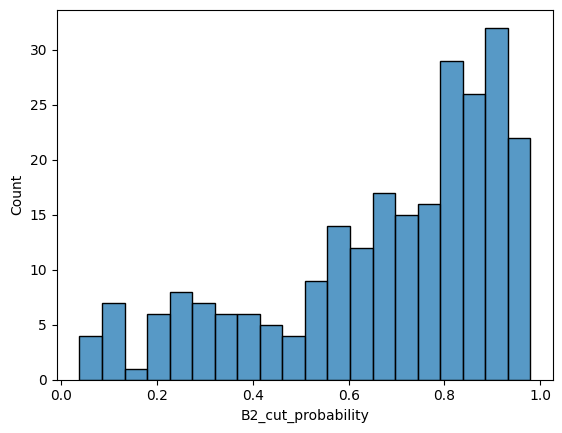

In [367]:
sns.histplot(data=df_var,x="B2_cut_probability",bins=20)

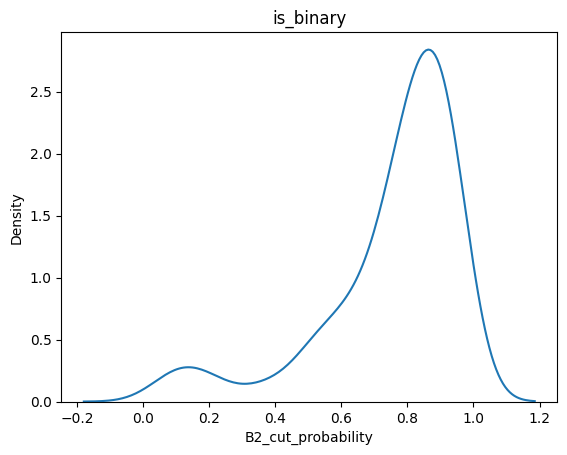

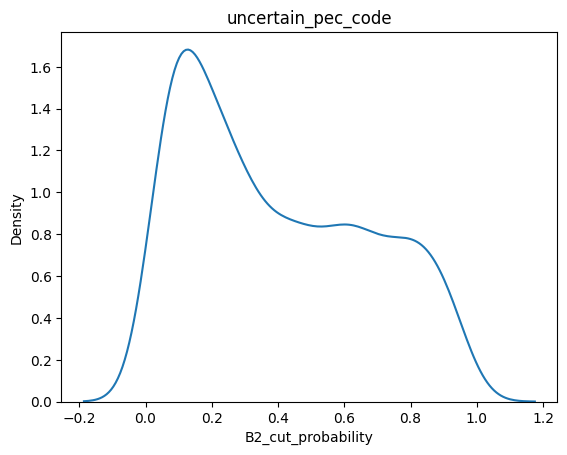

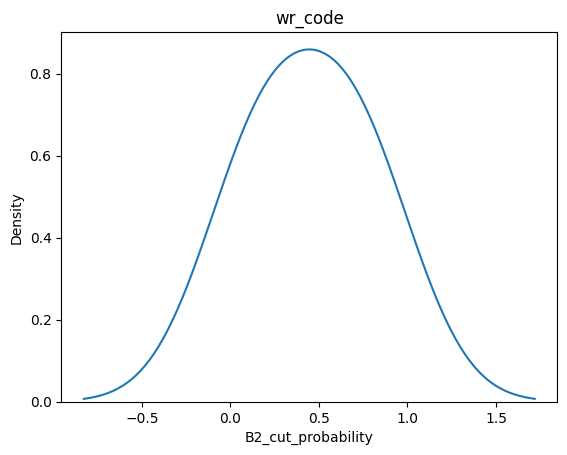

/tmp/ipykernel_52482/2154627089.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_var,x="B2_cut_probability")


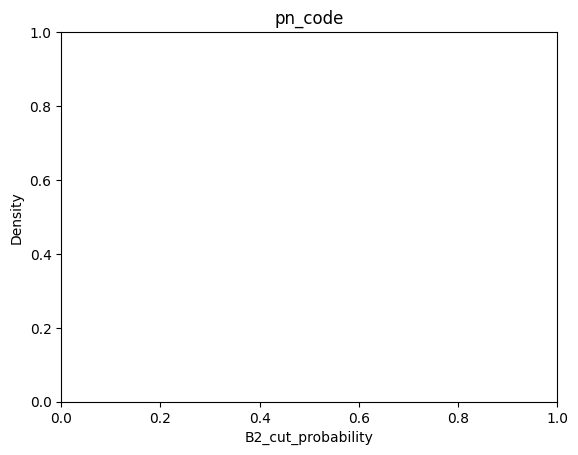

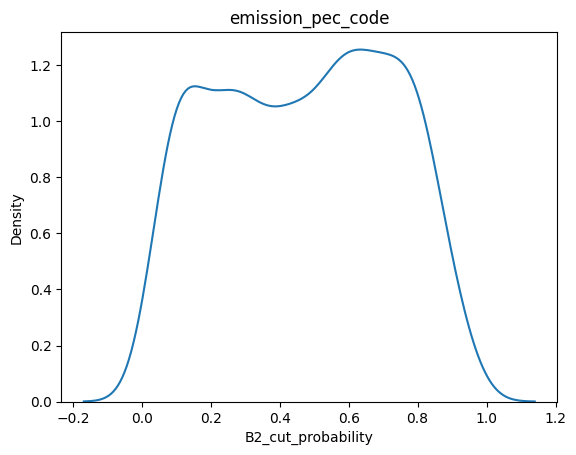

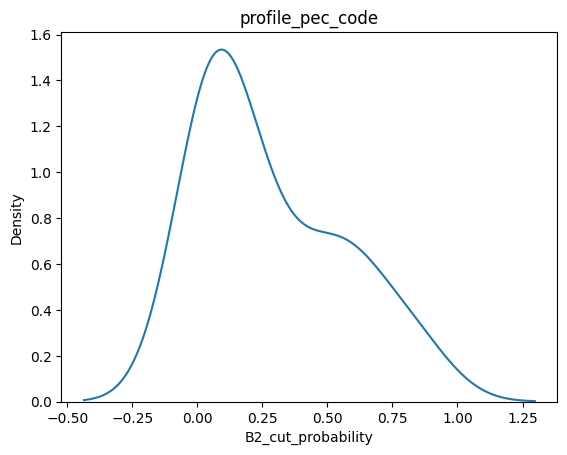

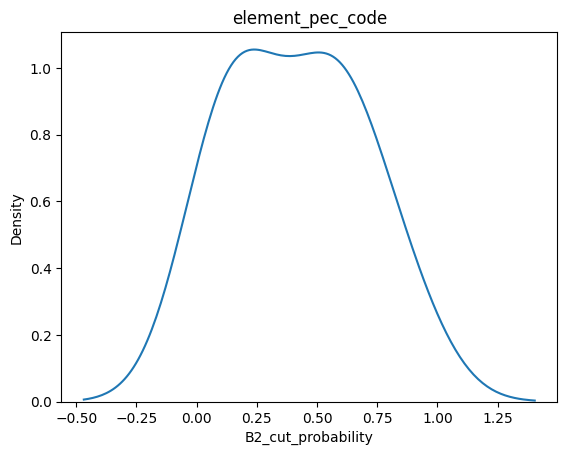

In [267]:
for coded in ['is_binary', 'uncertain_pec_code', 'wr_code', 'pn_code',
       'emission_pec_code', 'profile_pec_code', 'element_pec_code']:
    df_var = coded_alonso.loc[coded_alonso[coded]==1].reset_index(drop=True)
    sns.kdeplot(data=df_var,x="B2_cut_probability")
    plt.title(coded)
    plt.show()

In [260]:
coded_alonso.loc[coded_alonso["wd_type_code"].notna()] 

,index,source_id,Bibcode,ra,dec,skiff_type,type_code,is_binary,lum_class_code,wd_type_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code,uncertain_pec_code,GroupID_skiff,GroupSize_skiff,Sep_skiff,B2_cut_probability


In [258]:
coded_alonso.loc[coded_alonso["lum_class_code"].notna()]

,index,source_id,Bibcode,ra,dec,skiff_type,type_code,is_binary,lum_class_code,wd_type_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code,uncertain_pec_code,GroupID_skiff,GroupSize_skiff,Sep_skiff,B2_cut_probability
24,599,6056779927585101952,1970ApJ...161..855S,193.470818,-60.358575,B2Vn,12.0,0.0,4.0,NaN,0,0,0,2,0,0,NaN,NaN,0.122999,0.609167
39,810,6056407571106129152,2005A&A...437..467E,193.373008,-60.354541,B3Vn,13.0,0.0,4.0,NaN,0,0,0,2,0,0,NaN,NaN,0.674023,0.300833
47,961,3094450342504546944,1919AnHar..93.....C,121.215464,4.141434,B8III:,18.0,0.0,2.0,NaN,0,0,0,0,0,1,NaN,NaN,0.133384,0.145000
59,1178,2207265675751406848,1970AJ.....75.1001G,343.738805,62.571664,B2.5V,12.5,0.0,4.0,NaN,0,0,0,0,0,0,227.0,4.0,0.023597,0.306667
84,3236,5354159939788878208,1975MSS...C01....0H,158.557383,-53.632617,B7/8Vn(e),17.5,0.0,4.0,NaN,0,0,1,2,0,0,328.0,2.0,0.179259,0.195833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7635,1090438,5887717920201826816,1979A&AS...38..355L,225.911131,-54.299635,A5IV:,25.0,0.0,3.0,NaN,0,0,0,0,0,1,NaN,NaN,0.182929,0.098333
7646,1090604,468876464407828096,2011ApJS..193...24S,60.815203,56.540244,O9Ib,9.0,0.0,0.0,NaN,0,0,0,0,0,0,25844.0,10.0,0.024217,0.966667
7651,1090655,2055609732001730304,2016ApJS..224....4M,304.475763,34.817190,O9Iab,9.0,0.0,0.0,NaN,0,0,0,0,0,0,25853.0,5.0,0.144453,0.619167
7654,1090669,201623391420027648,1958ApJS....4....1M,74.322529,41.141782,F2V,32.0,0.0,4.0,NaN,0,0,0,0,0,0,25856.0,3.0,0.117132,0.075000


In [278]:
df_peculiarity["skiff_type"]

35465     OB
35466     OB
35467      A
35468     em
35469     Be
        ... 
99383    B7e
99384     B:
99385    OB-
99386    OB-
99387    OB-
Name: skiff_type, Length: 7663, dtype: object

In [250]:
coded_alonso.loc[coded_alonso["wr_code"]==1]

,index,source_id,Bibcode,ra,dec,skiff_type,type_code,is_binary,lum_class_code,wd_type_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code,uncertain_pec_code,GroupID_skiff,GroupSize_skiff,Sep_skiff,B2_cut_probability
1292,287096,2060661846184974464,1947AnDea...5....1L,304.250095,37.423249,WR,NaN,0.0,NaN,NaN,1,0,0,0,0,0,3918.0,19.0,0.132464,0.716667
3218,781723,5934367136201757824,1976ApJS...30..491H,246.780983,-51.422952,WR:,NaN,0.0,NaN,NaN,1,0,0,0,0,1,10618.0,4.0,0.047304,0.174167


In [252]:
coded_alonso.loc[coded_alonso["emission_pec_code"]==1]

,index,source_id,Bibcode,ra,dec,skiff_type,type_code,is_binary,lum_class_code,wd_type_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code,uncertain_pec_code,GroupID_skiff,GroupSize_skiff,Sep_skiff,B2_cut_probability
3,29,3002048553539426176,1950ApJ...112...72M,97.935959,-10.518866,em,NaN,0.0,NaN,NaN,0,0,1,0,2,0,11.0,3.0,0.018086,0.538333
4,57,6056404410010181888,1963MNRAS.126...11F,193.446857,-60.372235,Be,12.0,0.0,NaN,NaN,0,0,1,0,0,0,15.0,3.0,0.056207,0.801667
12,212,3128608664089787008,2015AJ....149....7C,104.805948,4.454975,Be,13.0,0.0,NaN,NaN,0,0,1,0,0,0,NaN,NaN,0.039859,0.096667
13,248,5618854582335486848,1977ApJS...33..459S,114.435129,-22.604155,B7e,17.0,0.0,NaN,NaN,0,0,1,0,0,0,NaN,NaN,0.044212,0.467500
22,577,4077123329309014016,1976ApJS...30..491H,277.456074,-24.524987,em,NaN,0.0,NaN,NaN,0,0,1,0,2,0,NaN,NaN,0.061591,0.077500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7633,1090394,4053981113432354304,1976ApJS...30..491H,266.910274,-33.008015,em,NaN,0.0,NaN,NaN,0,0,1,0,2,0,25811.0,2.0,0.069483,0.856667
7647,1090605,5425031946734235520,1981A&AS...44..387M,143.338367,-42.958890,em,NaN,0.0,NaN,NaN,0,0,1,0,2,0,NaN,NaN,0.020916,0.208333
7650,1090629,5964322334067272832,1976ApJS...30..491H,253.286469,-44.673191,em,NaN,0.0,NaN,NaN,0,0,1,0,2,0,25847.0,3.0,0.081532,0.893500
7652,1090665,1821570367002743424,1977PW&SO...2...71S,298.081557,18.355656,Be,14.0,0.0,NaN,NaN,0,0,1,0,0,0,25855.0,3.0,0.097669,0.625000


In [253]:
coded_alonso.loc[coded_alonso["profile_pec_code"]==1]

,index,source_id,Bibcode,ra,dec,skiff_type,type_code,is_binary,lum_class_code,wd_type_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code,uncertain_pec_code,GroupID_skiff,GroupSize_skiff,Sep_skiff,B2_cut_probability
1104,238586,1262118784661585408,1982MNRAS.201..901D,226.291752,22.960595,B2Vs,12.0,0.0,4.0,NaN,0,0,0,1,0,0,NaN,NaN,0.143689,0.080000
1116,240847,3441148864372328704,1979RA......9..479C,84.011219,26.268288,B3/4V He-s,13.5,0.0,4.0,NaN,0,0,0,1,1,0,NaN,NaN,0.072419,0.544167
1429,316207,3385660601327759616,1979RA......9..479C,99.666209,26.499896,A1V Ks,NaN,0.0,NaN,NaN,0,0,0,1,0,0,NaN,NaN,0.075237,0.078333
1760,398624,5350395383778723200,1988PASP..100.1431M,161.174039,-59.359151,B5V He-s,15.0,0.0,4.0,NaN,0,0,0,1,1,0,NaN,NaN,0.167503,0.560000
1894,427723,3442520127170919168,1979RA......9..479C,84.165831,27.911736,B0.5/1III/IV He-s,10.8,0.0,2.5,NaN,0,0,0,1,1,0,5745.0,2.0,0.051885,0.850833
1922,431561,3386161841188989184,1979RA......9..479C,101.050168,27.479854,B9.5IV/V Ks,NaN,0.0,NaN,NaN,0,0,0,1,0,0,NaN,NaN,0.026525,0.067500
2065,466163,3051968614828175104,1943ApJ....97..300N,108.492827,-7.327741,B5s,15.0,0.0,NaN,NaN,0,0,0,1,0,0,NaN,NaN,0.039855,0.627500
2095,474562,3386186030446657152,1979RA......9..479C,101.585538,27.816167,A1IV/V Ks,NaN,0.0,NaN,NaN,0,0,0,1,0,0,NaN,NaN,0.012506,0.051667
3233,787800,1930451189530028416,1982MNRAS.201..901D,346.794453,41.092931,B2Vs,12.0,0.0,4.0,NaN,0,0,0,1,0,0,NaN,NaN,0.049355,0.797500
3290,804712,1834613942151738496,1979RA......9..479C,299.299090,25.488879,B9/A0IV/V Ks,NaN,0.0,NaN,NaN,0,0,0,1,0,0,NaN,NaN,0.166665,0.104167


In [255]:
coded_alonso.loc[coded_alonso["uncertain_pec_code"]==1]

,index,source_id,Bibcode,ra,dec,skiff_type,type_code,is_binary,lum_class_code,wd_type_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code,uncertain_pec_code,GroupID_skiff,GroupSize_skiff,Sep_skiff,B2_cut_probability
14,259,5932551125286913920,1968AJ.....73..590D,243.266985,-54.387768,A1:,21.0,0.0,NaN,NaN,0,0,0,0,0,1,NaN,NaN,0.072334,0.475000
32,746,2012993623382709504,1955IzKry..14....3B,357.953855,62.391310,B8:,18.0,0.0,NaN,NaN,0,0,0,0,0,1,NaN,NaN,0.036224,0.350833
36,785,469027784690582912,1956ApJS....2..298M,62.341977,56.598714,A3m:,23.0,0.0,NaN,NaN,0,0,0,0,2,1,NaN,NaN,0.663770,0.065833
45,904,3130763324624263680,1985CBVMS.C......0V,100.716636,4.781346,B0:,10.0,0.0,NaN,NaN,0,0,0,0,0,1,NaN,NaN,0.188386,0.595000
46,958,3427856623489361280,1967AJ.....72.1199M,88.707060,23.905456,B5:,15.0,0.0,NaN,NaN,0,0,0,0,0,1,NaN,NaN,0.086996,0.245833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7632,1090389,3130884515720169216,1985CBVMS.C......0V,99.624093,4.641595,B5:,15.0,0.0,NaN,NaN,0,0,0,0,0,1,25810.0,2.0,0.369662,0.215833
7635,1090438,5887717920201826816,1979A&AS...38..355L,225.911131,-54.299635,A5IV:,25.0,0.0,3.0,NaN,0,0,0,0,0,1,NaN,NaN,0.182929,0.098333
7648,1090622,5335281325169850880,1976A&AS...23..283L,179.400861,-60.304390,OB:,18.0,0.0,NaN,NaN,0,0,0,0,0,1,NaN,NaN,0.099606,0.800128
7653,1090668,5932550163318920320,1968AJ.....73..590D,243.368404,-54.410583,B6:,16.0,0.0,NaN,NaN,0,0,0,0,0,1,NaN,NaN,0.102756,0.134167


In [248]:
coded_alonso.loc[coded_alonso["is_binary"]==1]

,index,source_id,Bibcode,ra,dec,skiff_type,type_code,is_binary,lum_class_code,wd_type_code,wr_code,pn_code,emission_pec_code,profile_pec_code,element_pec_code,uncertain_pec_code,GroupID_skiff,GroupSize_skiff,Sep_skiff,B2_cut_probability
25,610,459855418175704192,1959LS....C01....0H,45.367249,56.751437,OB+,4.0,1.0,NaN,NaN,0,0,0,0,0,0,NaN,NaN,0.164709,0.905833
72,1521,5876411436000552320,1964MeLu2.141....1L,226.185301,-60.459049,OB+,13.0,1.0,NaN,NaN,0,0,0,0,0,0,NaN,NaN,0.150794,0.939167
87,3785,5932739863365109888,1968AJ.....73..590D,240.266932,-54.302076,OB+:,7.0,1.0,NaN,NaN,0,0,0,0,0,0,335.0,4.0,0.091912,0.958333
175,21829,5884763837345122304,1980AJ.....85..265O,239.026917,-54.223958,OB+?,2.0,1.0,NaN,NaN,0,0,0,0,0,0,603.0,2.0,0.099470,0.917500
176,23135,5878661723932257408,1964MeLu2.141....1L,217.568487,-60.386547,OB+,1.0,1.0,NaN,NaN,0,0,0,0,0,0,620.0,2.0,0.119478,0.882500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7510,1088790,460547320226958464,1959LS....C01....0H,43.150822,56.554868,OB+,14.0,1.0,NaN,NaN,0,0,0,0,0,0,25480.0,2.0,0.032607,0.929167
7512,1088803,2015757383296979840,1964LS....C03....0H,352.507447,62.227954,OB+,17.0,1.0,NaN,NaN,0,0,0,0,0,0,25483.0,6.0,0.111617,0.929119
7522,1088990,5338236567554721280,1981AJ.....86..209F,163.551997,-60.283263,OB+,9.0,1.0,NaN,NaN,0,0,0,0,0,0,NaN,NaN,0.053765,0.830000
7528,1089064,5254219241943989120,2016AJ....152..190A,161.218351,-60.269524,B0V: + B2V,10.0,1.0,4.0,NaN,0,0,0,0,0,1,NaN,NaN,0.117479,0.797500


In [238]:
coded_alonso.rename(columns={'Unnamed: 0': 'index'}, inplace=True)

In [234]:
coded_alonso.keys()

Index(['index', 'original_skiff_ID', 'source_id', 'Bibcode', 'ra', 'dec',
       'skiff_type', 'type_code', 'lum_class_code', 'wd_type_code', 'wr_code',
       'pn_code', 'emission_pec_code', 'profile_pec_code', 'element_pec_code',
       'uncertain_pec_code', 'GroupID_skiff', 'GroupSize_skiff', 'Sep_skiff',
       'type_code_std_dev'],
      dtype='object')

In [232]:
df_peculiarity

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,Ksmag-Gmag,Ksmag-BPmag,Ksmag-RPmag,Gmag-BPmag,Gmag-RPmag,BPmag-RPmag,bp_rp,B2,B2_cut_split,B2_cut_probability
35465,0,194166159964132352,80.993351,40.911002,0.017015,0.012003,0.240222,0.018702,12.844826,-0.037741,...,-0.820414,-1.016462,-0.465843,-0.196048,0.354571,0.550619,0.354571,NaN,NaN,0.528333
35466,8,2058623012345486208,301.262602,34.967800,0.009757,0.011542,0.468671,0.013482,34.762420,-3.066021,...,-0.893568,-1.083399,-0.542640,-0.189831,0.350928,0.540759,0.350928,NaN,NaN,0.560000
35467,28,2058792715093466368,302.020494,34.929858,0.011634,0.012798,0.688046,0.015459,44.508570,-3.510020,...,-0.513275,-0.618708,-0.308246,-0.105433,0.205029,0.310462,0.205029,NaN,NaN,0.098333
35468,29,3002048553539426176,97.935959,-10.518866,0.012809,0.012502,0.637642,0.015105,42.214886,0.880935,...,-1.381199,-1.682779,-0.890982,-0.301580,0.490217,0.791797,0.490217,NaN,NaN,0.538333
35469,57,6056404410010181888,193.446857,-60.372235,0.010233,0.011742,0.485992,0.016196,30.007717,-4.726398,...,-1.210121,-1.350078,-0.910345,-0.139957,0.299776,0.439733,0.299776,NaN,NaN,0.801667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99383,1090775,5930430098664887296,248.531434,-54.448183,0.013537,0.009705,0.662841,0.017796,37.247540,-2.524056,...,-0.717239,-0.822202,-0.496207,-0.104963,0.221032,0.325995,0.221032,NaN,NaN,0.215000
99384,1090785,203937691597823488,69.770362,41.249985,0.016364,0.009660,1.189286,0.019677,60.441757,-1.227252,...,-0.390069,-0.481758,-0.181521,-0.091689,0.208548,0.300237,0.208548,NaN,NaN,0.450000
99385,1090787,5864090957158292352,203.339627,-64.428129,0.011969,0.013909,0.140483,0.017663,7.953494,-6.599529,...,-0.916823,-1.109537,-0.564549,-0.192714,0.352274,0.544988,0.352274,NaN,NaN,0.783333
99386,1090807,458308469733215488,35.288818,56.816726,0.012023,0.015792,0.459138,0.022097,20.778366,-0.777010,...,-0.324710,-0.389914,-0.136988,-0.065204,0.187722,0.252926,0.187722,NaN,NaN,0.907500


In [229]:
df_peculiarity.me`rge(coded_alonso[["index","skiff_type"]],how="left",on="index")['skiff_type_x']

0        OB
1        OB
2         A
3        em
4        Be
       ... 
7658    B7e
7659     B:
7660    OB-
7661    OB-
7662    OB-
Name: skiff_type_x, Length: 7663, dtype: object

In [211]:
df.loc[df["GroupID_skiff"]==10][["mk","skiff_type","index",
                "GroupID_skiff",'index_list',
                'source_id_list','std_sp',
               'label',"tmass_oid","ra","dec"]]

,mk,skiff_type,index,GroupID_skiff,index_list,source_id_list,std_sp,label,tmass_oid,ra,dec
28,NaN,A,28,10.0,NaN,NaN,NaN,NaN,392971926,302.020494,34.929858
47,NaN,B8,47,10.0,NaN,NaN,NaN,NaN,392971926,302.020494,34.929858


In [201]:
df_peculiarity[["B2","mk","skiff_type","index",
                "GroupID_skiff",'index_list',
                'source_id_list','std_sp',
               'label']]

,B2,mk,skiff_type,index,GroupID_skiff,index_list,source_id_list,std_sp,label
35465,NaN,NaN,OB,0,NaN,NaN,NaN,NaN,NaN
35466,NaN,NaN,OB,8,3.0,NaN,NaN,NaN,NaN
35467,NaN,NaN,A,28,10.0,NaN,NaN,NaN,NaN
35468,NaN,NaN,em,29,11.0,NaN,NaN,NaN,NaN
35469,NaN,NaN,Be,57,15.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
99383,NaN,NaN,B7e,1090775,NaN,NaN,NaN,NaN,NaN
99384,NaN,NaN,B:,1090785,25878.0,NaN,NaN,NaN,NaN
99385,NaN,NaN,OB-,1090787,NaN,NaN,NaN,NaN,NaN
99386,NaN,NaN,OB-,1090807,NaN,NaN,NaN,NaN,NaN


In [213]:
df_peculiarity.loc[df_peculiarity["skiff_type"].str[0] == "A"]

,index,source_id,ra,dec,ra_error,dec_error,Parallax,Parallax_error,Parallax_over_error,pmRA,...,Ksmag-Gmag,Ksmag-BPmag,Ksmag-RPmag,Gmag-BPmag,Gmag-RPmag,BPmag-RPmag,bp_rp,B2,B2_cut_split,B2_cut_probability
35467,28,2058792715093466368,302.020494,34.929858,0.011634,0.012798,0.688046,0.015459,44.508570,-3.510020,...,-0.513275,-0.618708,-0.308246,-0.105433,0.205029,0.310462,0.205029,NaN,NaN,0.098333
35473,121,4066052617233631488,271.245931,-24.456483,0.019205,0.015341,0.816531,0.020856,39.150475,1.621859,...,-0.977581,-1.131759,-0.667903,-0.154179,0.309678,0.463857,0.309678,NaN,NaN,0.126667
35479,259,5932551125286913920,243.266985,-54.387768,0.012760,0.008904,0.452958,0.018215,24.867315,-2.216387,...,-0.567373,-0.662632,-0.357669,-0.095259,0.209704,0.304963,0.209704,NaN,NaN,0.475000
35481,327,3035037647588853376,113.281141,-10.882482,0.015546,0.016439,0.851486,0.022776,37.384666,-1.585771,...,-0.288533,-0.297815,-0.194580,-0.009282,0.093953,0.103235,0.093953,NaN,NaN,0.083333
35495,693,1867892826209254912,316.296903,34.680272,0.009919,0.010660,1.679313,0.015231,110.258970,-4.557973,...,-0.561362,-0.666783,-0.350953,-0.105421,0.210409,0.315830,0.210409,NaN,NaN,0.040000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99342,1090253,4272594162818114816,278.854938,0.020838,0.107896,0.101160,1.701024,0.118664,14.334749,2.670964,...,-1.788176,-2.186785,-1.112801,-0.398609,0.675375,1.073984,0.675375,NaN,NaN,0.247500
99344,1090258,2171520694481020672,324.440830,51.231345,0.014153,0.014504,0.788563,0.015214,51.832590,-2.323159,...,-0.239497,-0.296350,-0.096918,-0.056853,0.142579,0.199432,0.142579,NaN,NaN,0.265000
99348,1090286,3424861897411791744,90.072805,23.672046,0.012791,0.010566,0.496766,0.014602,34.021500,0.271298,...,-1.268894,-1.520106,-0.833830,-0.251212,0.435064,0.686276,0.435064,NaN,NaN,0.466667
99352,1090345,4065825469347601792,272.349867,-24.526123,0.017187,0.017749,0.844189,0.027187,31.051086,0.158096,...,-0.942121,-1.114901,-0.625671,-0.172780,0.316450,0.489230,0.316450,NaN,NaN,0.375000


<Axes: xlabel='B2_cut_probability', ylabel='Count'>

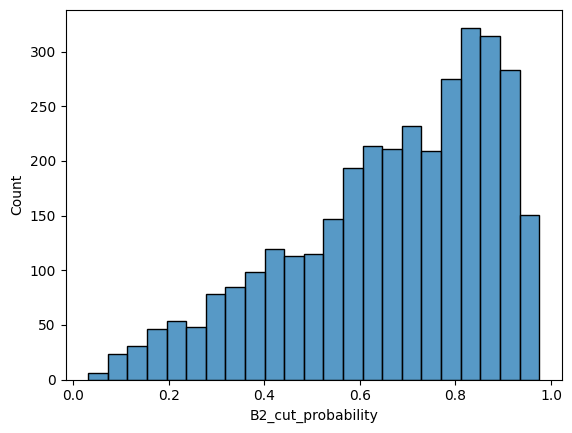

In [72]:
sns.histplot(data=OB,x="B2_cut_probability")